# Model Explainability using SHAP

## Objective

The objective of this notebook is to explain and validate the predictions of the
final churn prediction model using SHAP (SHapley Additive exPlanations).

SHAP is used as a post-modeling interpretability tool to:
- Understand global feature impact on churn predictions
- Explain individual customer predictions
- Validate that the model relies on meaningful and business-aligned features

This analysis is exploratory and explanatory in nature and does not modify
the production training pipeline.


## Model Used for Explainability

Based on prior model comparison results, the Gradient Boosting classifier was
selected for SHAP analysis as it achieved the highest ROC-AUC and demonstrated
strong recall for churners.

Tree-based models are also well-supported by SHAP, enabling efficient and
reliable explanation of feature contributions.


## Imports and Setup


In [ ]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import shap
import sys

# Add project root to PYTHONPATH
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils.config import MODELS_DIR, PROCESSED_DATA_PATH

## Load Trained Model and Dataset


In [2]:
# Load dataset
df = pd.read_csv(PROCESSED_DATA_PATH / "telco_customer_churn_selected_features.csv")

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

# Load trained Gradient Boosting model
model = joblib.load(MODELS_DIR / "gradient_boosting" / "gradient_boosting_tuned.joblib")

## SHAP Explainer Initialization


In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

## Global Feature Importance (SHAP Summary Plot)


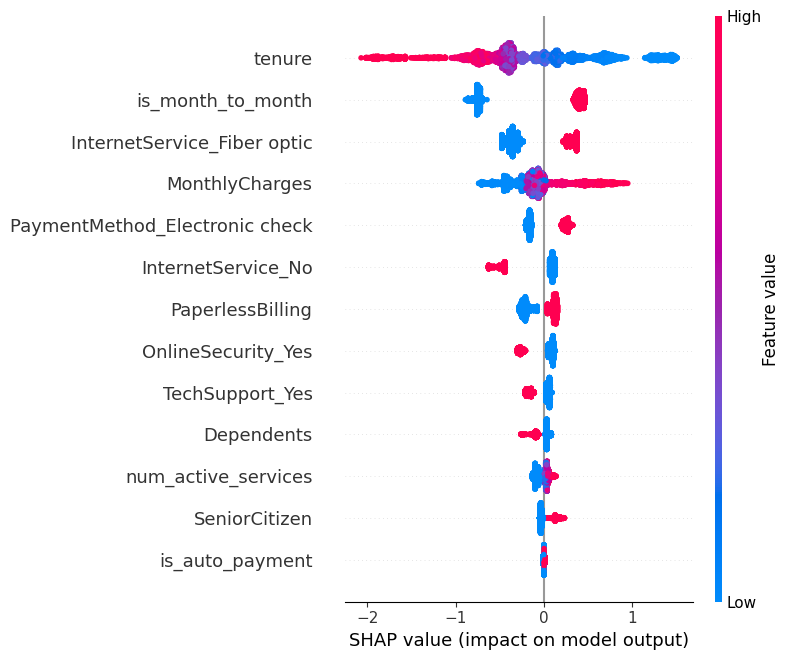

In [14]:
shap.summary_plot(shap_values.values, X, feature_names=X.columns, show=False)

### Global SHAP Interpretation

The SHAP summary plot identifies customer tenure and contract flexibility as the
primary drivers of churn predictions. Customers with shorter tenure consistently
exhibit higher churn risk, while longer tenure strongly reduces the likelihood
of churn.

Month-to-month contracts have a pronounced positive impact on churn probability,
indicating that customers without long-term contractual commitment are more
likely to discontinue the service.

Pricing and service-related factors provide secondary but meaningful influence.
Higher monthly charges and fiber optic internet service are associated with
increased churn risk, while value-added services such as online security and
technical support consistently mitigate churn probability.

Overall, the SHAP analysis confirms that the model relies on stable,
interpretable, and business-aligned features. The observed feature effects are
consistent with prior exploratory analysis and feature selection decisions,
validating the robustness of the final model.


---

## Business Interpretation

The SHAP findings translate into clear and actionable retention insights.
Customers in early stages of their lifecycle and those subscribed to
month-to-month contracts represent the most volatile segment, requiring
proactive engagement to reduce early churn.

Furthermore, customers without value-added services such as online security and
technical support exhibit lower switching costs, making them more likely to
churn. This highlights opportunities to increase perceived value through
service bundling. Pricing sensitivity among high-risk customers also suggests
that retention efforts should focus on targeted offers rather than uniform price
reductions.

Overall, churn risk emerges as a function of customer commitment, service
adoption, and perceived value, providing concrete levers for retention
strategies.

---

## Business Action Mapping

| Feature Insight | Risk Interpretation | Suggested Business Action |
|-----------------|---------------------|---------------------------|
| Short tenure | High early churn risk |  Proactive onboarding, welcome offers, and early customer engagement campaigns |
| Month-to-month contract | Low customer commitment | Contract upgrade offers and loyalty discounts |
| No support services | Low switching cost | Bundle internet service with security and technical support offerings |
| High monthly charges | Price sensitivity | Targeted pricing adjustments or value-based retention offers |

## Local Explanation – Individual Prediction

In [19]:
# Select a single customer (example)
sample_idx = 0

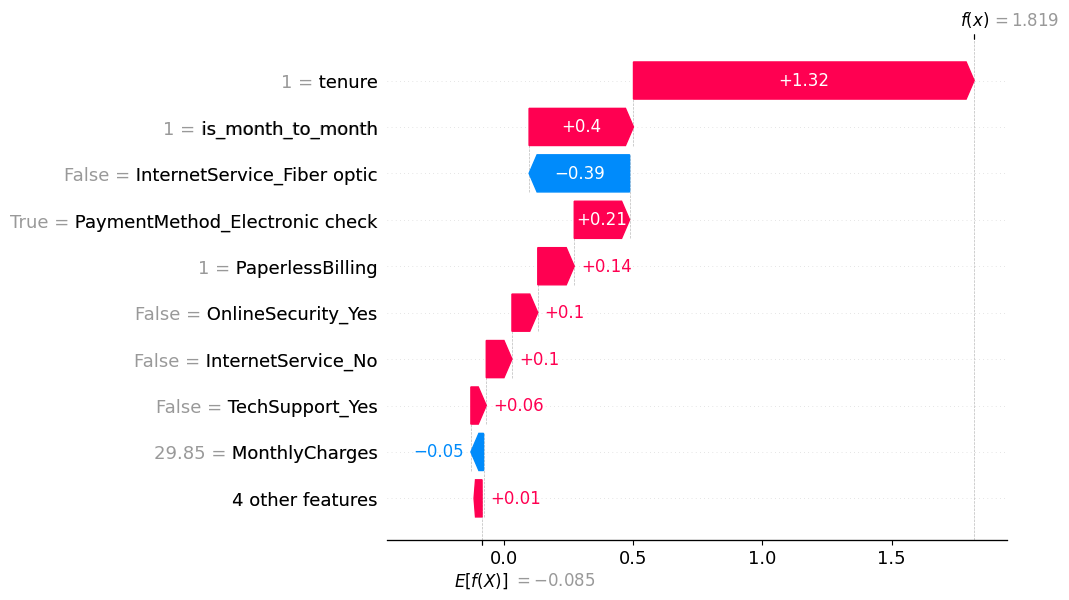

In [20]:
shap.plots.waterfall(shap_values[sample_idx])

In [23]:
log_odds = shap_values.base_values[sample_idx] + shap_values.values[sample_idx].sum()
probability = 1 / (1 + np.exp(-log_odds))
print(
    f"Predicted probability of churn for customer {sample_idx}: {probability * 100:.2f}%"
)

Predicted probability of churn for customer 0: 86.04%


### Local SHAP Interpretation

This waterfall plot explains the churn prediction for an individual customer.
Starting from the baseline model output, short tenure and a month-to-month
contract contribute strongly to increasing churn risk. The absence of value-added
services such as online security and technical support further amplifies this
risk, while lower monthly charges partially offset it.

Although the customer does not use fiber optic internet service, which slightly
reduces churn probability, the combined effect of contractual flexibility,
limited tenure, and lack of support services results in a high predicted churn
risk. The final model output corresponds to a churn probability of approximately
86%, indicating a strong likelihood of customer attrition.


---

## Conclusion

This SHAP analysis provided transparent explanations for the final churn
prediction model, validating that predictions are driven by meaningful and
business-aligned features. The results strengthen confidence in the model’s
interpretability and suitability for decision support.
